<a href="https://colab.research.google.com/github/Rodrivdlc/Sistema-basado-en-Inteligencia-Artificial-para-la-detecci-n-de-enfermedades-en-cultivos/blob/main/notebooks/03_entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/TFG/dataset/archive.zip" -d "/content/dataset"

In [ ]:
dataset_path = "/content/dataset/PlantVillage"

In [ ]:
clases = os.listdir(dataset_path)

clases_tomate = [
    clase for clase in clases
    if clase.lower().startswith("tomato")
]

tomato_path = "/content/tomato_dataset"
os.makedirs(tomato_path, exist_ok=True)

for clase in clases_tomate:
    origen = os.path.join(dataset_path, clase)
    destino = os.path.join(tomato_path, clase)

    if not os.path.exists(destino):
        shutil.copytree(origen, destino)

In [ ]:
split_base = "/content/tomato_split"

train_path = os.path.join(split_base, "train")
val_path = os.path.join(split_base, "val")
test_path = os.path.join(split_base, "test")

for ruta in [train_path, val_path, test_path]:
    os.makedirs(ruta, exist_ok=True)

In [ ]:
random.seed(42)

for clase in os.listdir(tomato_path):
    clase_path = os.path.join(tomato_path, clase)

    imagenes = [
        img for img in os.listdir(clase_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(imagenes)

    total = len(imagenes)

    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    train_imgs = imagenes[:train_end]
    val_imgs = imagenes[train_end:val_end]
    test_imgs = imagenes[val_end:]

    for destino_base, lista in [
        (train_path, train_imgs),
        (val_path, val_imgs),
        (test_path, test_imgs)
    ]:
        destino_clase = os.path.join(destino_base, clase)
        os.makedirs(destino_clase, exist_ok=True)

        for imagen in lista:
            shutil.copy2(
                os.path.join(clase_path, imagen),
                os.path.join(destino_clase, imagen)
            )

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 11203 files belonging to 10 classes.
Found 2402 files belonging to 10 classes.
Found 2406 files belonging to 10 classes.


In [ ]:
class_names = train_ds.class_names

print(class_names)
print("Número de clases:", len(class_names))

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Número de clases: 10


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
print(class_names)
print("Número de clases:", len(class_names))

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Número de clases: 10


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - accuracy: 0.7028 - loss: 0.9167 - val_accuracy: 0.8201 - val_loss: 0.5785
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.8298 - loss: 0.5296 - val_accuracy: 0.8472 - val_loss: 0.4777
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.8569 - loss: 0.4410 - val_accuracy: 0.8597 - val_loss: 0.4268
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8697 - loss: 0.3989 - val_accuracy: 0.8618 - val_loss: 0.4155
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.8741 - loss: 0.3719 - val_accuracy: 0.8730 - val_loss: 0.3979
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.8790 - loss: 0.3567 - val_accuracy: 0.8693 - val_loss: 0.3999
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.8930 - loss: 0.3268 - val_accuracy: 0.8709 - val_loss: 0.3952
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.8841 - loss: 0.3396 - 

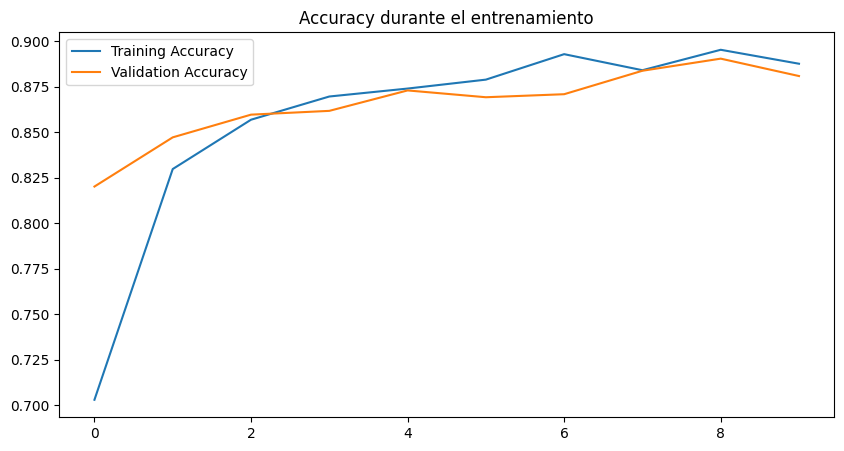

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")

plt.legend()
plt.title("Accuracy durante el entrenamiento")

plt.show()

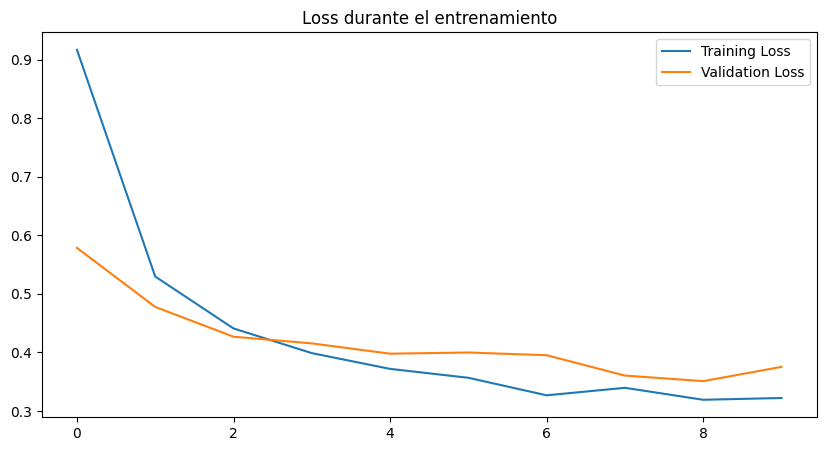

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.legend()
plt.title("Loss durante el entrenamiento")

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8741 - loss: 0.3646
Test accuracy: 0.8740648627281189
Test loss: 0.36457955837249756


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/TFG/models",
    exist_ok=True
)

In [ ]:
model.save(
    "/content/drive/MyDrive/TFG/models/modelo_tomate_mobilenetv2.keras"
)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8741 - loss: 0.3646
Test accuracy: 0.8741
Test accuracy: 87.41%
Test loss: 0.3646


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.77      0.98      0.86       320
                        Tomato_Early_blight       0.92      0.51      0.66       150
                         Tomato_Late_blight       0.91      0.92      0.92       287
                           Tomato_Leaf_Mold       0.85      0.84      0.85       143
                  Tomato_Septoria_leaf_spot       0.93      0.75      0.83       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.87      0.81      0.84       252
                        Tomato__Target_Spot       0.68      0.89      0.77       211
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.98      0.95      0.97       482
                Tomato__Tomato_mosaic_virus       0.98      0.84      0.90        56
                             Tomato_healthy       0.93      0.97      0.95       239

                                   accuracy                    

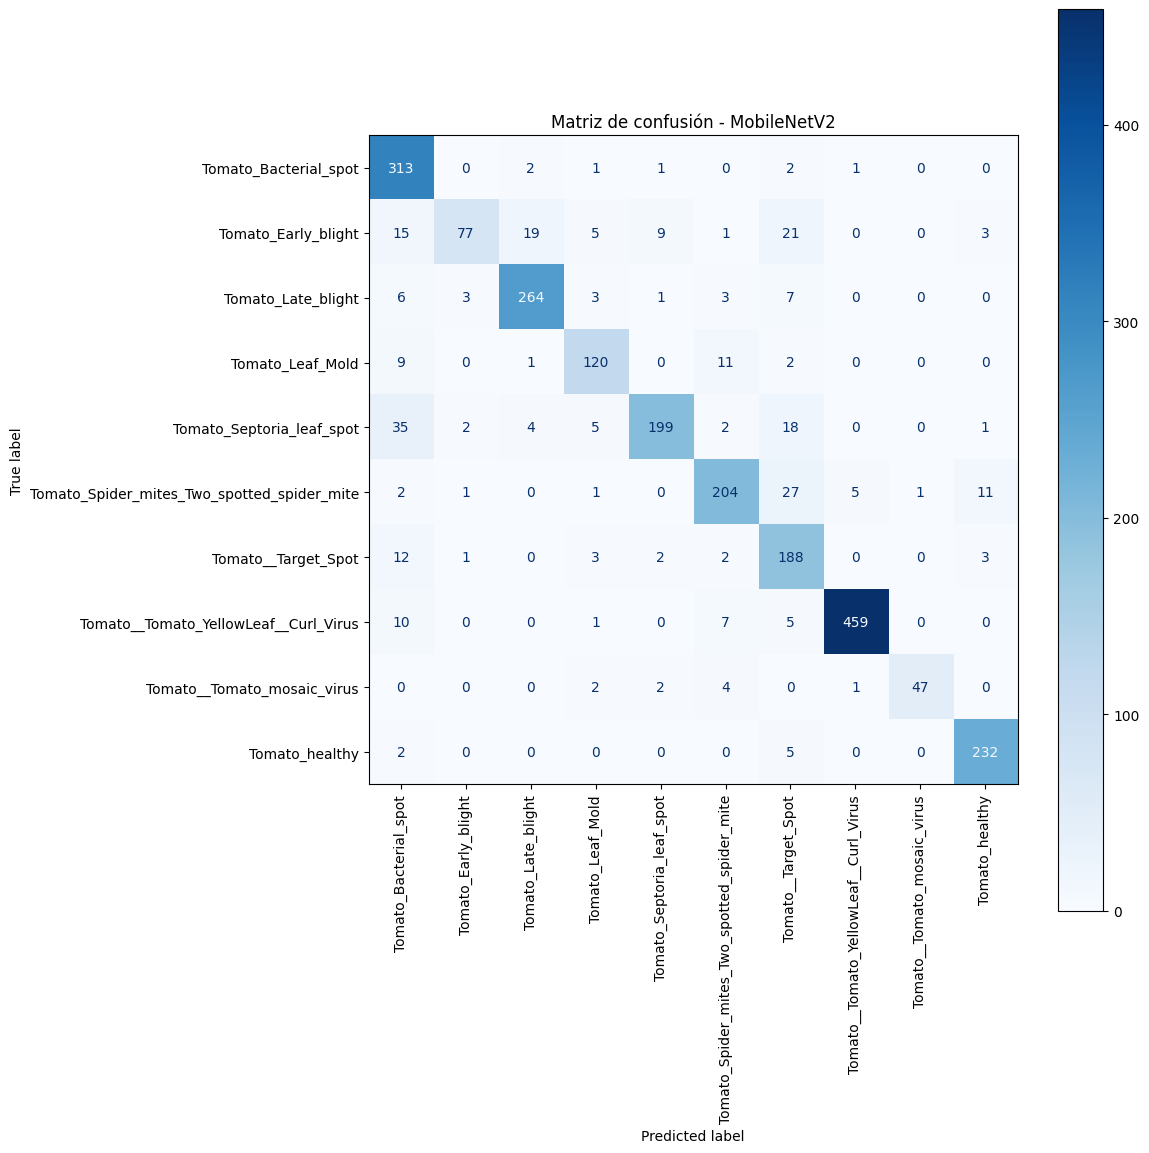

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Matriz de confusión - MobileNetV2")
plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
print("Número total de capas:", len(base_model.layers))

print(
    "Capas entrenables:",
    len([layer for layer in base_model.layers if layer.trainable])
)

Número total de capas: 154
Capas entrenables: 54


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 54s 110ms/step - accuracy: 0.7219 - loss: 1.1131 - val_accuracy: 0.8855 - val_loss: 0.3693
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.8490 - loss: 0.4377 - val_accuracy: 0.8872 - val_loss: 0.3819
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.8801 - loss: 0.3495 - val_accuracy: 0.8930 - val_loss: 0.3758
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.8986 - loss: 0.2946 - val_accuracy: 0.9047 - val_loss: 0.3367
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.9086 - loss: 0.2555 - val_accuracy: 0.9013 - val_loss: 0.3184
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.9250 - loss: 0.2155 - val_accuracy: 0.9101 - val_loss: 0.2847
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.9330 - loss: 0.1933 - val_accuracy: 0.9130 - val_loss: 0.2818
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9390 - loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9306 - loss: 0.2062
Test accuracy: 93.06%
Test loss: 0.2062


In [ ]:
y_true_fine = []
y_pred_fine = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_fine.extend(labels.numpy())
    y_pred_fine.extend(predicted_classes)

y_true_fine = np.array(y_true_fine)
y_pred_fine = np.array(y_pred_fine)

In [ ]:
print(
    classification_report(
        y_true_fine,
        y_pred_fine,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.95      0.96      0.95       320
                        Tomato_Early_blight       0.95      0.69      0.80       150
                         Tomato_Late_blight       0.97      0.94      0.96       287
                           Tomato_Leaf_Mold       0.96      0.92      0.94       143
                  Tomato_Septoria_leaf_spot       0.87      0.94      0.90       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.84      0.90       252
                        Tomato__Target_Spot       0.82      0.95      0.88       211
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.97      0.98       482
                Tomato__Tomato_mosaic_virus       0.92      0.98      0.95        56
                             Tomato_healthy       0.89      1.00      0.94       239

                                   accuracy                    

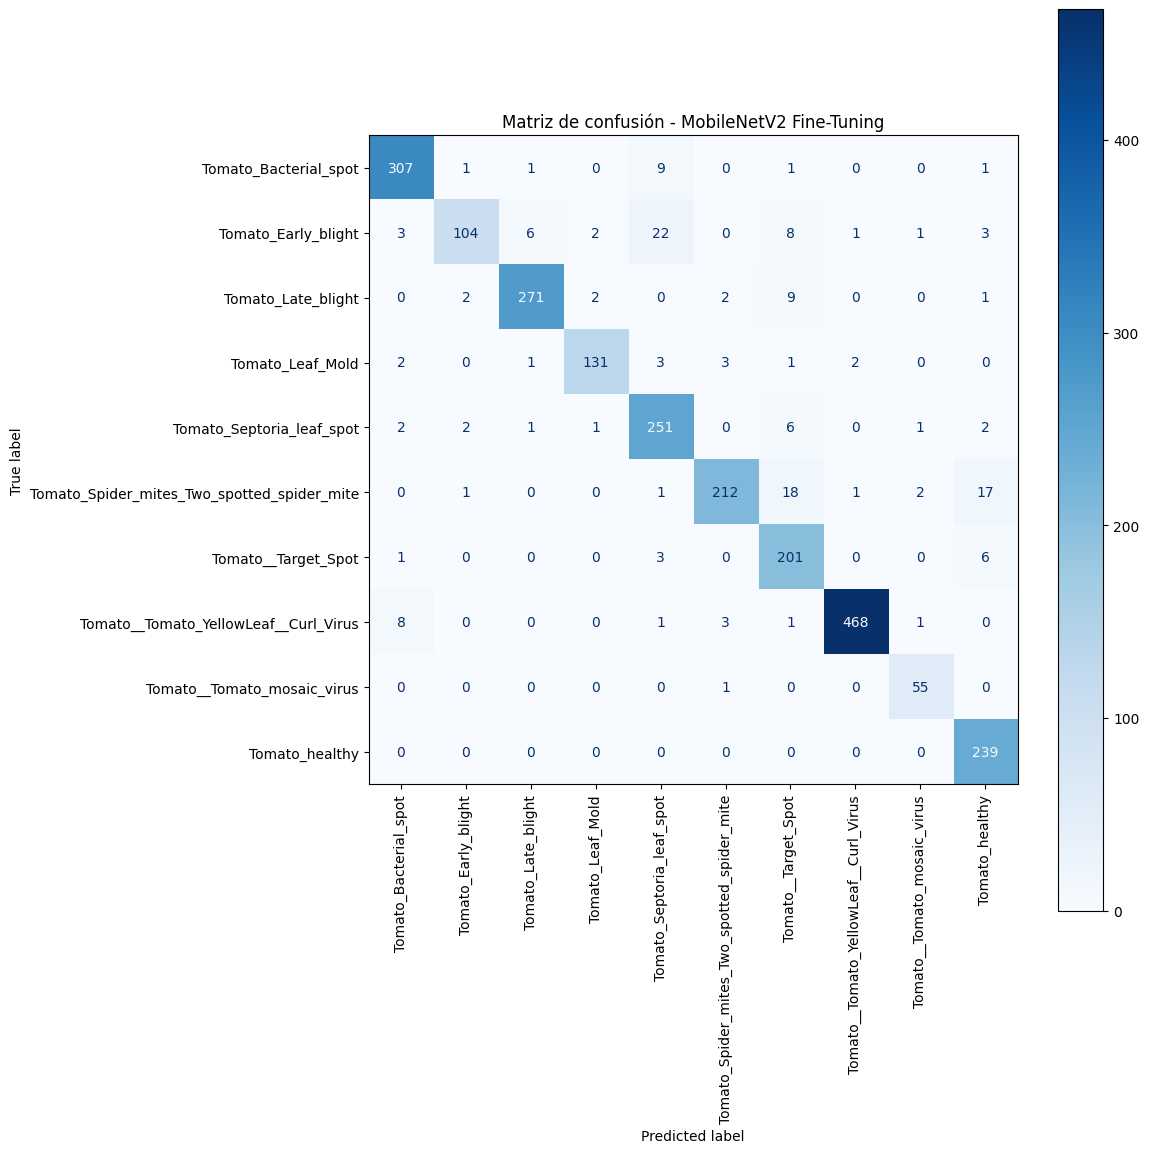

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_true_fine,
    y_pred_fine,
    display_labels=class_names,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Matriz de confusión - MobileNetV2 Fine-Tuning")
plt.tight_layout()
plt.show()

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/TFG/models",
    exist_ok=True
)

model.save(
    "/content/drive/MyDrive/TFG/models/modelo_tomate_mobilenetv2_finetuned.keras"
)

In [ ]:
import json

with open(
    "/content/drive/MyDrive/TFG/models/class_names.json",
    "w"
) as f:
    json.dump(class_names, f)